# GABLS1 Stable Boundary Layer: Vertical Profiles


*Last updated: May 8, 2026*


This notebook summarizes the JAX-ALFA simulations of the GABLS1 stable boundary-layer benchmark after Beare et al. (2006). The case begins from a 265 K neutral boundary layer and is driven by a prescribed surface cooling rate of 0.25 K hr$^{-1}$.

| Quantity | Value |
| --- | --- |
| Domain | 400 m x 400 m x 400 m |
| Geostrophic wind | $U_g = 8$ m s$^{-1}$ |
| Coriolis parameter | $f = 1.39 \times 10^{-4}$ s$^{-1}$ |
| Roughness length | $z_0 = 0.1$ m |
| Resolutions compared | $40^3$, $80^3$, $100^3$ |
| Averaging window | 8-9 h |

The figures below compare mean profiles, variances, resolved and SGS fluxes, and the temporal evolution of the wind and temperature structure.


## Setup

The next cells load Python packages, locate the simulation outputs, and define the grid and averaging window used throughout the notebook.


In [1]:
import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

### Output directories


In [2]:
from pathlib import Path

# Base directory (JAXALFA0.1/) — 4 levels above notebook's cwd
BaseDir = Path(__file__).parents[5] if '__file__' in dir() else Path.cwd().parents[4]

# 40x40x40 run
OutputDir1 = BaseDir / 'examples/SBL_GABLS1/runs/40x40x40/output'

# 80x80x80 run
OutputDir2 = BaseDir / 'examples/SBL_GABLS1/runs/80x80x80/output'

# 100x100x100 run
OutputDir3 = BaseDir / 'examples/SBL_GABLS1/runs/100x100x100/output'


### Case configuration


In [3]:
nz_1 = 40     # 40x40x40 run
nz_2 = 80     # 80x80x80 run
nz_3 = 100    # 100x100x100 run

l_z = 400     # domain height (m)
dt  = 0.4     # timestep (s) — same output interval for all runs

# Statistics output every 60 s (150 iters × 0.4 s / 300 iters × 0.2 s / 600 iters × 0.1 s)
OutputInterval_sec = 60.0

# Averaging window — GABLS1 quasi-steady state (hours 8–9)
T_start = 8 * 3600   # s
T_end   = 9 * 3600   # s


### Derived grid and averaging indices


In [4]:
# Half levels — u, v, TH
z_1 = np.array([(k + 0.5) * l_z / (nz_1 - 1) for k in range(nz_1)])
z_2 = np.array([(k + 0.5) * l_z / (nz_2 - 1) for k in range(nz_2)])
z_3 = np.array([(k + 0.5) * l_z / (nz_3 - 1) for k in range(nz_3)])

# Full levels — w, uw, vw, wTH, qz
z_w_1 = np.array([k * l_z / (nz_1 - 1) for k in range(nz_1)])
z_w_2 = np.array([k * l_z / (nz_2 - 1) for k in range(nz_2)])
z_w_3 = np.array([k * l_z / (nz_3 - 1) for k in range(nz_3)])

# File indices for the averaging window (same for all runs: same OutputInterval_sec)
T_start_index = int(T_start / OutputInterval_sec) - 1
T_end_index   = int(T_end   / OutputInterval_sec) - 1

print(f'Run 1 (40³):  dz = {l_z/(nz_1-1):.3f} m')
print(f'Run 2 (80³):  dz = {l_z/(nz_2-1):.3f} m')
print(f'Run 3 (100³): dz = {l_z/(nz_3-1):.3f} m')
print(f'Averaging window: file indices {T_start_index} – {T_end_index}')


Run 1 (40³):  dz = 10.256 m
Run 2 (80³):  dz = 5.063 m
Run 3 (100³): dz = 4.040 m
Averaging window: file indices 479 – 539


### Statistics loader


In [5]:
def LoadStatsAverage(stat_files, T_start_index, T_end_index):

    U   = []; V   = []; TH  = []
    u2  = []; v2  = []; w2  = []; TH2 = []
    uv  = []; uw  = []; vw  = []
    txy = []; txz = []; tyz = []
    wTH = []; qz  = []

    for f in stat_files:
        with np.load(f) as d:
            U.append(d['U']);   V.append(d['V']);   TH.append(d['TH'])
            u2.append(d['u2']); v2.append(d['v2']); w2.append(d['w2'])
            TH2.append(d['TH2'])
            uv.append(d['uv']); uw.append(d['uw']); vw.append(d['vw'])
            txy.append(d['txy']); txz.append(d['txz']); tyz.append(d['tyz'])
            wTH.append(d['wTH']); qz.append(d['qz'])

    U  = np.array(U);  V  = np.array(V);  TH  = np.array(TH)
    u2 = np.array(u2); v2 = np.array(v2); w2  = np.array(w2); TH2 = np.array(TH2)
    uv = np.array(uv); uw = np.array(uw); vw  = np.array(vw)
    txy = np.array(txy); txz = np.array(txz); tyz = np.array(tyz)
    wTH = np.array(wTH); qz = np.array(qz)

    sl = slice(T_start_index, T_end_index + 1)

    return (
        np.mean(U[sl],   axis=0), np.mean(V[sl],   axis=0), np.mean(TH[sl],  axis=0),
        np.mean(u2[sl],  axis=0), np.mean(v2[sl],  axis=0), np.mean(w2[sl],  axis=0),
        np.mean(TH2[sl], axis=0),
        np.mean(uv[sl],  axis=0), np.mean(uw[sl],  axis=0), np.mean(vw[sl],  axis=0),
        np.mean(txy[sl], axis=0), np.mean(txz[sl], axis=0), np.mean(tyz[sl], axis=0),
        np.mean(wTH[sl], axis=0), np.mean(qz[sl],  axis=0)
    )

### Available statistics files


In [6]:
def get_stat_files(output_dir):
    files = sorted(
        glob.glob(str(output_dir / 'ALFA_Statistics_Iteration_*.npz')),
        key=lambda x: int(re.search(r'Iteration_(\d+)', x).group(1))
    )
    return files

StatFiles1 = get_stat_files(OutputDir1)
StatFiles2 = get_stat_files(OutputDir2)
StatFiles3 = get_stat_files(OutputDir3)

# Time axis (hours) based on run 1
t_hours = np.array([
    int(re.search(r'Iteration_(\d+)', f).group(1)) * dt / 3600.0
    for f in StatFiles1
])

print(f'Run 1 (40x40x40):    {len(StatFiles1)} files,  {t_hours[-1]:.2f} h')
print(f'Run 2 (80x80x80):    {len(StatFiles2)} files')
print(f'Run 3 (100x100x100): {len(StatFiles3)} files')


Run 1 (40x40x40):    540 files,  9.00 h
Run 2 (80x80x80):    540 files
Run 3 (100x100x100): 540 files


### Temporally averaged profiles


In [7]:
(U_avg_1, V_avg_1, TH_avg_1,
 u2_avg_1, v2_avg_1, w2_avg_1, TH2_avg_1,
 uv_avg_1, uw_avg_1, vw_avg_1,
 txy_avg_1, txz_avg_1, tyz_avg_1,
 wTH_avg_1, qz_avg_1) = LoadStatsAverage(StatFiles1, T_start_index, T_end_index)

(U_avg_2, V_avg_2, TH_avg_2,
 u2_avg_2, v2_avg_2, w2_avg_2, TH2_avg_2,
 uv_avg_2, uw_avg_2, vw_avg_2,
 txy_avg_2, txz_avg_2, tyz_avg_2,
 wTH_avg_2, qz_avg_2) = LoadStatsAverage(StatFiles2, T_start_index, T_end_index)

(U_avg_3, V_avg_3, TH_avg_3,
 u2_avg_3, v2_avg_3, w2_avg_3, TH2_avg_3,
 uv_avg_3, uw_avg_3, vw_avg_3,
 txy_avg_3, txz_avg_3, tyz_avg_3,
 wTH_avg_3, qz_avg_3) = LoadStatsAverage(StatFiles3, T_start_index, T_end_index)

S_avg_1   = np.sqrt(U_avg_1**2 + V_avg_1**2)
uw_tot_1  = uw_avg_1  + txz_avg_1
vw_tot_1  = vw_avg_1  + tyz_avg_1
wTH_tot_1 = wTH_avg_1 + qz_avg_1

S_avg_2   = np.sqrt(U_avg_2**2 + V_avg_2**2)
uw_tot_2  = uw_avg_2  + txz_avg_2
vw_tot_2  = vw_avg_2  + tyz_avg_2
wTH_tot_2 = wTH_avg_2 + qz_avg_2

S_avg_3   = np.sqrt(U_avg_3**2 + V_avg_3**2)
uw_tot_3  = uw_avg_3  + txz_avg_3
vw_tot_3  = vw_avg_3  + tyz_avg_3
wTH_tot_3 = wTH_avg_3 + qz_avg_3

print(f'Averaging over {T_end_index - T_start_index + 1} files '
      f'({T_start/3600:.1f}–{T_end/3600:.1f} h)')


Averaging over 61 files (8.0–9.0 h)


In [8]:
plt.rcParams.update({
    "text.usetex": True,
    "font.size": 14,
    "axes.labelsize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})


In [9]:
def plot_profile(x, z, xlabel, ylabel=r"$z$ (m)", linestyle='-k', label=None, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 6))

    ax.plot(x, z, linestyle, linewidth=2, label=label)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(False)


## Mean Wind and Hodograph

The first comparison shows the mean streamwise and cross-stream wind components, the wind-speed magnitude, and the hodograph over the 8-9 h averaging window.


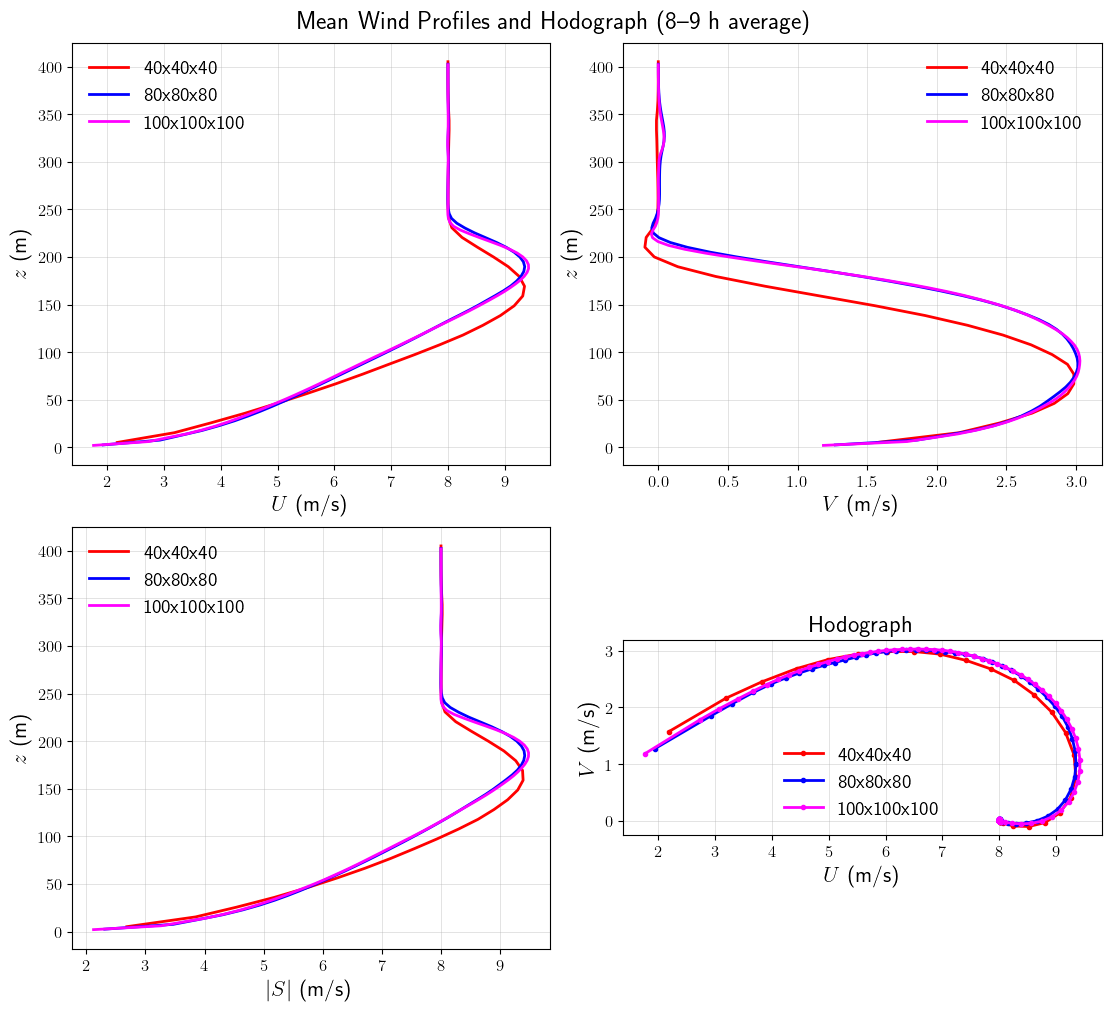

In [10]:
fig, axs = plt.subplots(2, 2, figsize=(11, 10), constrained_layout=True)
axs = axs.ravel()

run_styles = {
    '40x40x40': {'color': 'red', 'linestyle': '-'},
    '80x80x80': {'color': 'blue', 'linestyle': '-'},
    '100x100x100': {'color': 'magenta', 'linestyle': '-'},
}

def plot_run_profile(ax, x, z, xlabel, run_label):
    style = run_styles[run_label]
    ax.plot(x, z, color=style['color'], linestyle=style['linestyle'], linewidth=2, label=run_label)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"$z$ (m)")

plot_run_profile(axs[0], U_avg_1, z_1, r"$U$ (m/s)", '40x40x40')
plot_run_profile(axs[0], U_avg_2, z_2, r"$U$ (m/s)", '80x80x80')
plot_run_profile(axs[0], U_avg_3, z_3, r"$U$ (m/s)", '100x100x100')

plot_run_profile(axs[1], V_avg_1, z_1, r"$V$ (m/s)", '40x40x40')
plot_run_profile(axs[1], V_avg_2, z_2, r"$V$ (m/s)", '80x80x80')
plot_run_profile(axs[1], V_avg_3, z_3, r"$V$ (m/s)", '100x100x100')

plot_run_profile(axs[2], S_avg_1, z_1, r"$|S|$ (m/s)", '40x40x40')
plot_run_profile(axs[2], S_avg_2, z_2, r"$|S|$ (m/s)", '80x80x80')
plot_run_profile(axs[2], S_avg_3, z_3, r"$|S|$ (m/s)", '100x100x100')

axs[3].plot(U_avg_1, V_avg_1, color='red', linestyle='-', marker='o', linewidth=2, markersize=3, label='40x40x40')
axs[3].plot(U_avg_2, V_avg_2, color='blue', linestyle='-', marker='o', linewidth=2, markersize=3, label='80x80x80')
axs[3].plot(U_avg_3, V_avg_3, color='magenta', linestyle='-', marker='o', linewidth=2, markersize=3, label='100x100x100')
axs[3].set_xlabel(r"$U$ (m/s)")
axs[3].set_ylabel(r"$V$ (m/s)")
axs[3].set_title('Hodograph')
axs[3].set_aspect('equal')

for ax in axs:
    ax.grid()
    ax.legend(frameon=False)

fig.suptitle("Mean Wind Profiles and Hodograph (8--9 h average)", fontsize=18)
plt.show()


## Mean Potential Temperature and Temperature Variance

The two panels compare the horizontally averaged potential-temperature profile and the resolved temperature variance over the 8-9 h averaging window.


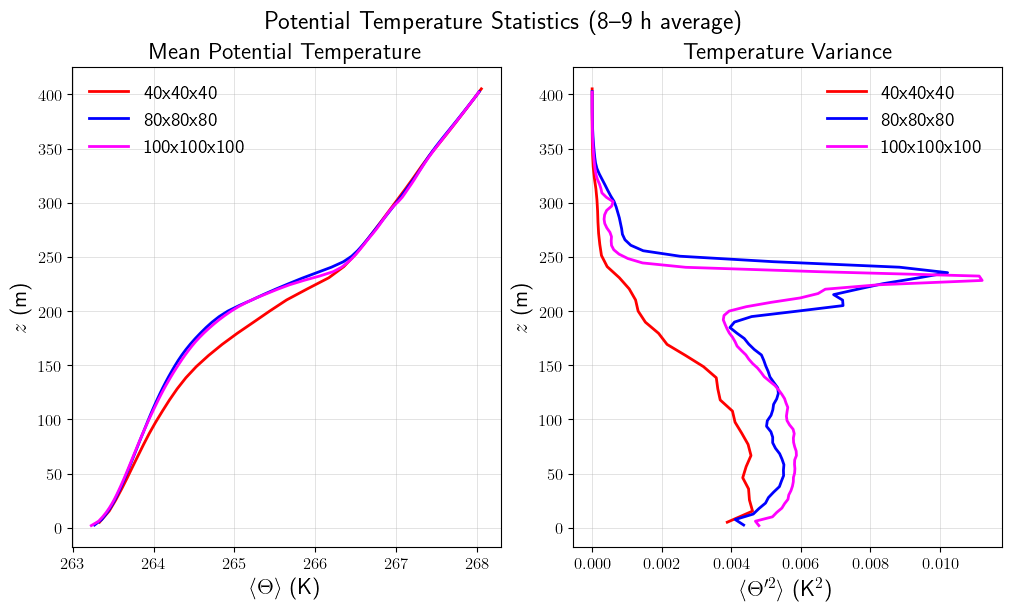

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(10, 6), constrained_layout=True)

run_styles = {
    '40x40x40': {'color': 'red', 'linestyle': '-'},
    '80x80x80': {'color': 'blue', 'linestyle': '-'},
    '100x100x100': {'color': 'magenta', 'linestyle': '-'},
}

def plot_run_profile(ax, x, z, xlabel, run_label):
    style = run_styles[run_label]
    ax.plot(x, z, color=style['color'], linestyle=style['linestyle'], linewidth=2, label=run_label)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"$z$ (m)")

plot_run_profile(axs[0], TH_avg_1, z_1, r"$\langle \Theta \rangle$ (K)", '40x40x40')
plot_run_profile(axs[0], TH_avg_2, z_2, r"$\langle \Theta \rangle$ (K)", '80x80x80')
plot_run_profile(axs[0], TH_avg_3, z_3, r"$\langle \Theta \rangle$ (K)", '100x100x100')
axs[0].set_title("Mean Potential Temperature")

plot_run_profile(axs[1], TH2_avg_1, z_1, r"$\langle \Theta^{\prime 2} \rangle$ (K$^2$)", '40x40x40')
plot_run_profile(axs[1], TH2_avg_2, z_2, r"$\langle \Theta^{\prime 2} \rangle$ (K$^2$)", '80x80x80')
plot_run_profile(axs[1], TH2_avg_3, z_3, r"$\langle \Theta^{\prime 2} \rangle$ (K$^2$)", '100x100x100')
axs[1].set_title("Temperature Variance")

for ax in axs:
    ax.grid()
    ax.legend(frameon=False)

fig.suptitle("Potential Temperature Statistics (8--9 h average)", fontsize=18)
plt.show()


## Resolved Velocity Variances

The resolved variance profiles indicate how the resolved turbulent kinetic energy is distributed among the three velocity components.


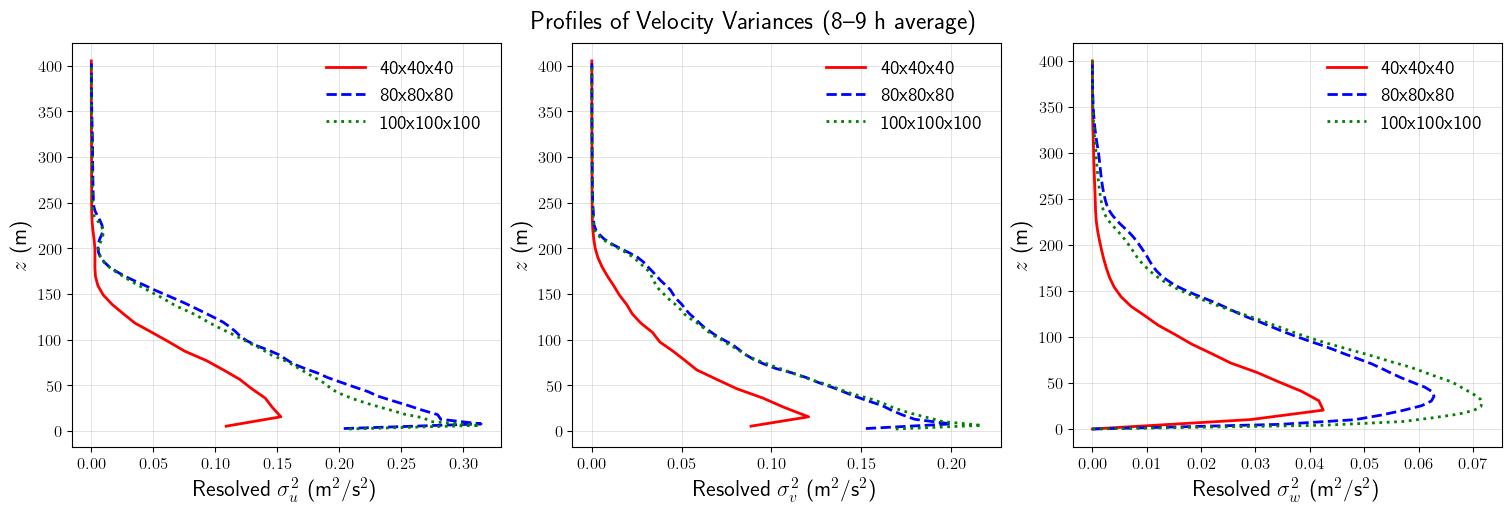

In [12]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

plot_profile(u2_avg_1, z_1,   xlabel=r"Resolved $\sigma_u^2$ (m$^2$/s$^2$)", linestyle='-r',  ax=axs[0], label='40x40x40')
plot_profile(v2_avg_1, z_1,   xlabel=r"Resolved $\sigma_v^2$ (m$^2$/s$^2$)", linestyle='-r',  ax=axs[1], label='40x40x40')
plot_profile(w2_avg_1, z_w_1, xlabel=r"Resolved $\sigma_w^2$ (m$^2$/s$^2$)", linestyle='-r',  ax=axs[2], label='40x40x40')
plot_profile(u2_avg_2, z_2,   xlabel=r"Resolved $\sigma_u^2$ (m$^2$/s$^2$)", linestyle='--b', ax=axs[0], label='80x80x80')
plot_profile(v2_avg_2, z_2,   xlabel=r"Resolved $\sigma_v^2$ (m$^2$/s$^2$)", linestyle='--b', ax=axs[1], label='80x80x80')
plot_profile(w2_avg_2, z_w_2, xlabel=r"Resolved $\sigma_w^2$ (m$^2$/s$^2$)", linestyle='--b', ax=axs[2], label='80x80x80')
plot_profile(u2_avg_3, z_3,   xlabel=r"Resolved $\sigma_u^2$ (m$^2$/s$^2$)", linestyle=':g',  ax=axs[0], label='100x100x100')
plot_profile(v2_avg_3, z_3,   xlabel=r"Resolved $\sigma_v^2$ (m$^2$/s$^2$)", linestyle=':g',  ax=axs[1], label='100x100x100')
plot_profile(w2_avg_3, z_w_3, xlabel=r"Resolved $\sigma_w^2$ (m$^2$/s$^2$)", linestyle=':g',  ax=axs[2], label='100x100x100')
axs[0].grid(); axs[0].legend(frameon=False)
axs[1].grid(); axs[1].legend(frameon=False)
axs[2].grid(); axs[2].legend(frameon=False)

fig.suptitle("Profiles of Velocity Variances (8--9 h average)", fontsize=18)
plt.show()


## Resolved Turbulent Kinetic Energy

The resolved TKE is computed from the three resolved velocity variances, with $w^2$ interpolated from full levels to the scalar half levels.


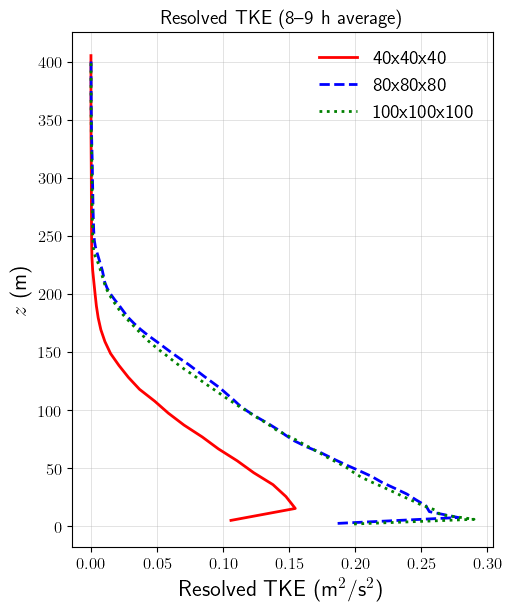

In [13]:
w2_half_1 = 0.5 * (w2_avg_1[:-1] + w2_avg_1[1:])
w2_half_1 = np.append(w2_half_1, w2_avg_1[-1])
TKE_avg_1 = 0.5 * (u2_avg_1 + v2_avg_1 + w2_half_1)

w2_half_2 = 0.5 * (w2_avg_2[:-1] + w2_avg_2[1:])
w2_half_2 = np.append(w2_half_2, w2_avg_2[-1])
TKE_avg_2 = 0.5 * (u2_avg_2 + v2_avg_2 + w2_half_2)

w2_half_3 = 0.5 * (w2_avg_3[:-1] + w2_avg_3[1:])
w2_half_3 = np.append(w2_half_3, w2_avg_3[-1])
TKE_avg_3 = 0.5 * (u2_avg_3 + v2_avg_3 + w2_half_3)

fig, ax = plt.subplots(figsize=(5, 6), constrained_layout=True)
plot_profile(TKE_avg_1, z_1, xlabel=r"Resolved TKE (m$^2$/s$^2$)", linestyle='-r',  ax=ax, label='40x40x40')
plot_profile(TKE_avg_2, z_2, xlabel=r"Resolved TKE (m$^2$/s$^2$)", linestyle='--b', ax=ax, label='80x80x80')
plot_profile(TKE_avg_3, z_3, xlabel=r"Resolved TKE (m$^2$/s$^2$)", linestyle=':g',  ax=ax, label='100x100x100')
ax.grid()
ax.legend(frameon=False)
ax.set_title("Resolved TKE (8--9 h average)", fontsize=14)
plt.show()


## Resolved Momentum Fluxes

These profiles show the resolved turbulent momentum fluxes before adding the SGS contribution.


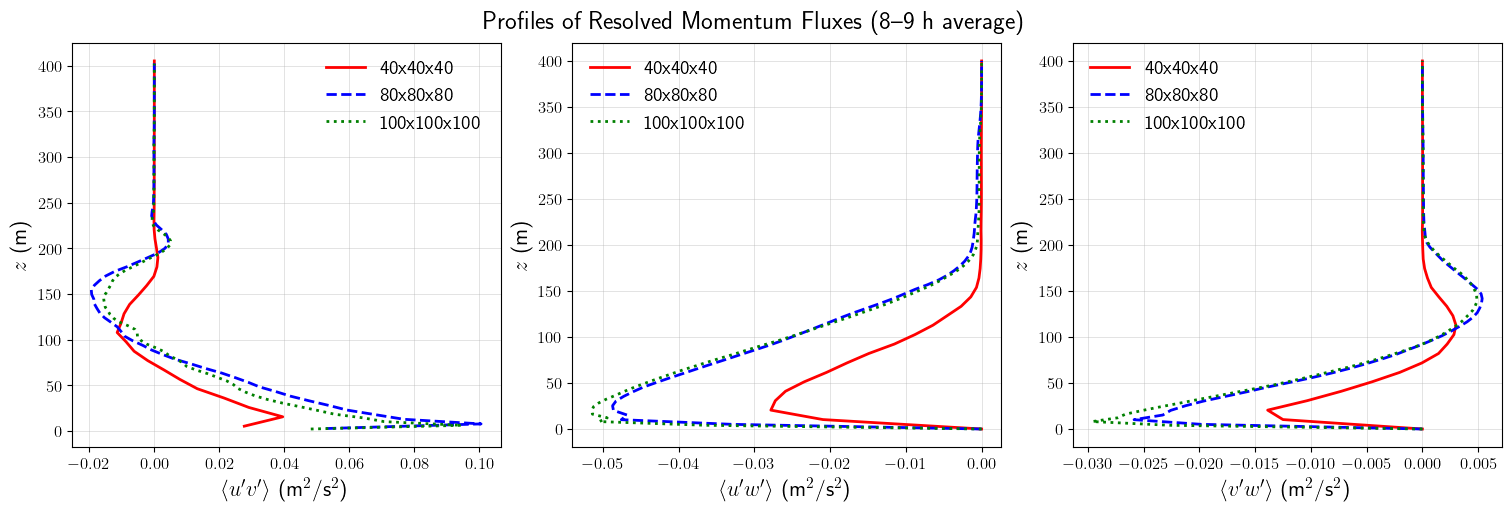

In [14]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

plot_profile(uv_avg_1, z_1,   xlabel=r"$\langle u'v' \rangle$ (m$^2$/s$^2$)", linestyle='-r',  ax=axs[0], label='40x40x40')
plot_profile(uw_avg_1, z_w_1, xlabel=r"$\langle u'w' \rangle$ (m$^2$/s$^2$)", linestyle='-r',  ax=axs[1], label='40x40x40')
plot_profile(vw_avg_1, z_w_1, xlabel=r"$\langle v'w' \rangle$ (m$^2$/s$^2$)", linestyle='-r',  ax=axs[2], label='40x40x40')
plot_profile(uv_avg_2, z_2,   xlabel=r"$\langle u'v' \rangle$ (m$^2$/s$^2$)", linestyle='--b', ax=axs[0], label='80x80x80')
plot_profile(uw_avg_2, z_w_2, xlabel=r"$\langle u'w' \rangle$ (m$^2$/s$^2$)", linestyle='--b', ax=axs[1], label='80x80x80')
plot_profile(vw_avg_2, z_w_2, xlabel=r"$\langle v'w' \rangle$ (m$^2$/s$^2$)", linestyle='--b', ax=axs[2], label='80x80x80')
plot_profile(uv_avg_3, z_3,   xlabel=r"$\langle u'v' \rangle$ (m$^2$/s$^2$)", linestyle=':g',  ax=axs[0], label='100x100x100')
plot_profile(uw_avg_3, z_w_3, xlabel=r"$\langle u'w' \rangle$ (m$^2$/s$^2$)", linestyle=':g',  ax=axs[1], label='100x100x100')
plot_profile(vw_avg_3, z_w_3, xlabel=r"$\langle v'w' \rangle$ (m$^2$/s$^2$)", linestyle=':g',  ax=axs[2], label='100x100x100')
axs[0].grid(); axs[0].legend(frameon=False)
axs[1].grid(); axs[1].legend(frameon=False)
axs[2].grid(); axs[2].legend(frameon=False)

fig.suptitle("Profiles of Resolved Momentum Fluxes (8--9 h average)", fontsize=18)
plt.show()


## Total Momentum Fluxes

The total vertical momentum flux combines resolved and SGS contributions. The 40$^3$ resolved and SGS components are shown separately for reference.


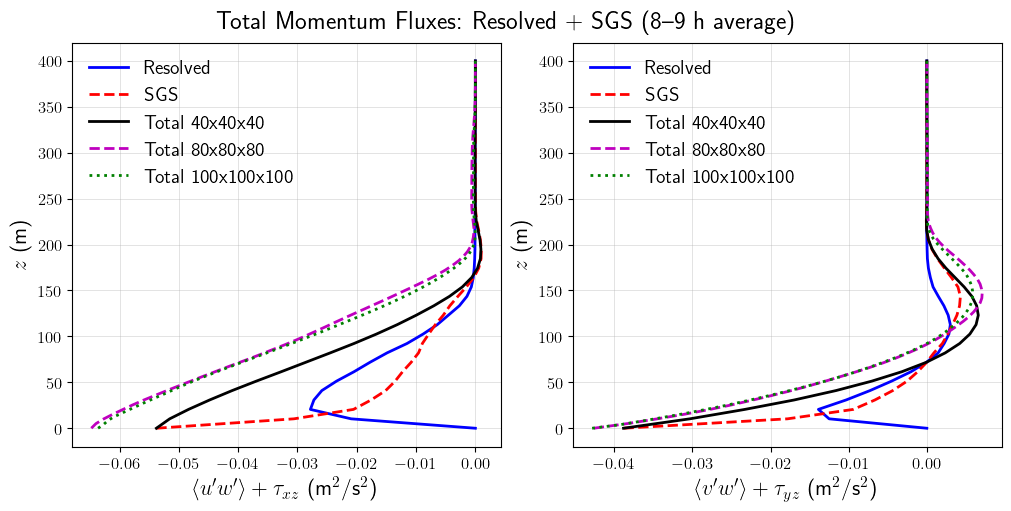

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

plot_profile(uw_avg_1,  z_w_1, xlabel=r"$\langle u'w' \rangle + \tau_{xz}$ (m$^2$/s$^2$)", linestyle='-b',  label='Resolved',          ax=axs[0])
plot_profile(txz_avg_1, z_w_1, xlabel=r"$\langle u'w' \rangle + \tau_{xz}$ (m$^2$/s$^2$)", linestyle='--r', label='SGS',               ax=axs[0])
plot_profile(uw_tot_1,  z_w_1, xlabel=r"$\langle u'w' \rangle + \tau_{xz}$ (m$^2$/s$^2$)", linestyle='-k',  label='Total 40x40x40',   ax=axs[0])
plot_profile(uw_tot_2,  z_w_2, xlabel=r"$\langle u'w' \rangle + \tau_{xz}$ (m$^2$/s$^2$)", linestyle='--m', label='Total 80x80x80',   ax=axs[0])
plot_profile(uw_tot_3,  z_w_3, xlabel=r"$\langle u'w' \rangle + \tau_{xz}$ (m$^2$/s$^2$)", linestyle=':g',  label='Total 100x100x100', ax=axs[0])
axs[0].grid()
axs[0].legend(frameon=False)

plot_profile(vw_avg_1,  z_w_1, xlabel=r"$\langle v'w' \rangle + \tau_{yz}$ (m$^2$/s$^2$)", linestyle='-b',  label='Resolved',          ax=axs[1])
plot_profile(tyz_avg_1, z_w_1, xlabel=r"$\langle v'w' \rangle + \tau_{yz}$ (m$^2$/s$^2$)", linestyle='--r', label='SGS',               ax=axs[1])
plot_profile(vw_tot_1,  z_w_1, xlabel=r"$\langle v'w' \rangle + \tau_{yz}$ (m$^2$/s$^2$)", linestyle='-k',  label='Total 40x40x40',   ax=axs[1])
plot_profile(vw_tot_2,  z_w_2, xlabel=r"$\langle v'w' \rangle + \tau_{yz}$ (m$^2$/s$^2$)", linestyle='--m', label='Total 80x80x80',   ax=axs[1])
plot_profile(vw_tot_3,  z_w_3, xlabel=r"$\langle v'w' \rangle + \tau_{yz}$ (m$^2$/s$^2$)", linestyle=':g',  label='Total 100x100x100', ax=axs[1])
axs[1].grid()
axs[1].legend(frameon=False)

fig.suptitle("Total Momentum Fluxes: Resolved + SGS (8--9 h average)", fontsize=18)
plt.show()


## Vertical Heat Fluxes

Resolved, SGS, and total heat-flux profiles are compared across the three grid resolutions.


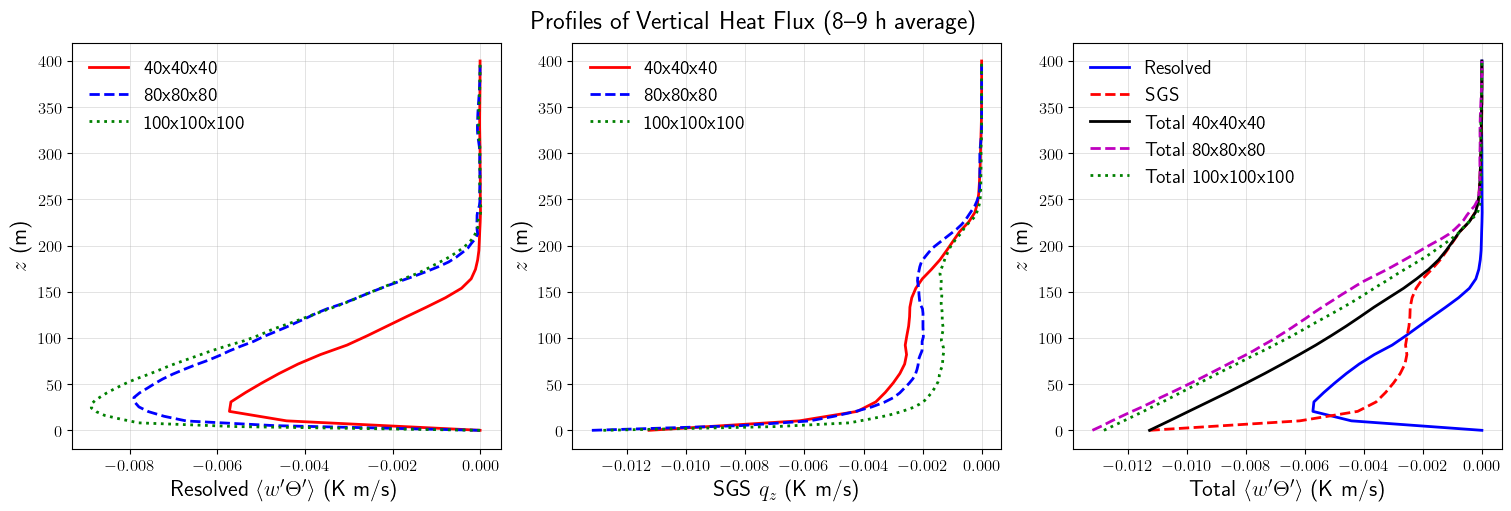

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

plot_profile(wTH_avg_1, z_w_1, xlabel=r"Resolved $\langle w'\Theta' \rangle$ (K m/s)", linestyle='-r',  ax=axs[0], label='40x40x40')
plot_profile(qz_avg_1,  z_w_1, xlabel=r"SGS $q_z$ (K m/s)",                            linestyle='-r',  ax=axs[1], label='40x40x40')
plot_profile(wTH_avg_2, z_w_2, xlabel=r"Resolved $\langle w'\Theta' \rangle$ (K m/s)", linestyle='--b', ax=axs[0], label='80x80x80')
plot_profile(qz_avg_2,  z_w_2, xlabel=r"SGS $q_z$ (K m/s)",                            linestyle='--b', ax=axs[1], label='80x80x80')
plot_profile(wTH_avg_3, z_w_3, xlabel=r"Resolved $\langle w'\Theta' \rangle$ (K m/s)", linestyle=':g',  ax=axs[0], label='100x100x100')
plot_profile(qz_avg_3,  z_w_3, xlabel=r"SGS $q_z$ (K m/s)",                            linestyle=':g',  ax=axs[1], label='100x100x100')
axs[0].grid(); axs[0].legend(frameon=False)
axs[1].grid(); axs[1].legend(frameon=False)

plot_profile(wTH_avg_1, z_w_1, xlabel=r"Total $\langle w'\Theta' \rangle$ (K m/s)", linestyle='-b',  label='Resolved',          ax=axs[2])
plot_profile(qz_avg_1,  z_w_1, xlabel=r"Total $\langle w'\Theta' \rangle$ (K m/s)", linestyle='--r', label='SGS',               ax=axs[2])
plot_profile(wTH_tot_1, z_w_1, xlabel=r"Total $\langle w'\Theta' \rangle$ (K m/s)", linestyle='-k',  label='Total 40x40x40',   ax=axs[2])
plot_profile(wTH_tot_2, z_w_2, xlabel=r"Total $\langle w'\Theta' \rangle$ (K m/s)", linestyle='--m', label='Total 80x80x80',   ax=axs[2])
plot_profile(wTH_tot_3, z_w_3, xlabel=r"Total $\langle w'\Theta' \rangle$ (K m/s)", linestyle=':g',  label='Total 100x100x100', ax=axs[2])
axs[2].grid(); axs[2].legend(frameon=False)

fig.suptitle("Profiles of Vertical Heat Flux (8--9 h average)", fontsize=18)
plt.show()


## SGS Stresses

The SGS stress profiles show the modeled stress contribution retained by each grid resolution.


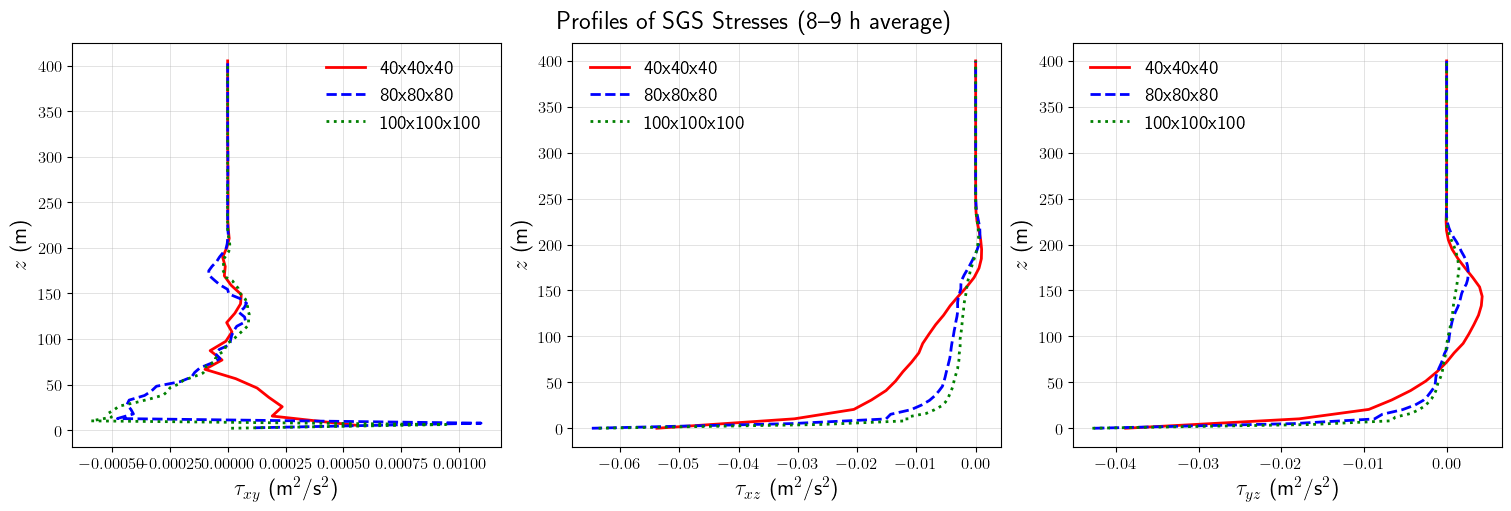

In [17]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

plot_profile(txy_avg_1, z_1,   xlabel=r"$\tau_{xy}$ (m$^2$/s$^2$)", linestyle='-r',  ax=axs[0], label='40x40x40')
plot_profile(txz_avg_1, z_w_1, xlabel=r"$\tau_{xz}$ (m$^2$/s$^2$)", linestyle='-r',  ax=axs[1], label='40x40x40')
plot_profile(tyz_avg_1, z_w_1, xlabel=r"$\tau_{yz}$ (m$^2$/s$^2$)", linestyle='-r',  ax=axs[2], label='40x40x40')
plot_profile(txy_avg_2, z_2,   xlabel=r"$\tau_{xy}$ (m$^2$/s$^2$)", linestyle='--b', ax=axs[0], label='80x80x80')
plot_profile(txz_avg_2, z_w_2, xlabel=r"$\tau_{xz}$ (m$^2$/s$^2$)", linestyle='--b', ax=axs[1], label='80x80x80')
plot_profile(tyz_avg_2, z_w_2, xlabel=r"$\tau_{yz}$ (m$^2$/s$^2$)", linestyle='--b', ax=axs[2], label='80x80x80')
plot_profile(txy_avg_3, z_3,   xlabel=r"$\tau_{xy}$ (m$^2$/s$^2$)", linestyle=':g',  ax=axs[0], label='100x100x100')
plot_profile(txz_avg_3, z_w_3, xlabel=r"$\tau_{xz}$ (m$^2$/s$^2$)", linestyle=':g',  ax=axs[1], label='100x100x100')
plot_profile(tyz_avg_3, z_w_3, xlabel=r"$\tau_{yz}$ (m$^2$/s$^2$)", linestyle=':g',  ax=axs[2], label='100x100x100')
axs[0].grid(); axs[0].legend(frameon=False)
axs[1].grid(); axs[1].legend(frameon=False)
axs[2].grid(); axs[2].legend(frameon=False)

fig.suptitle("Profiles of SGS Stresses (8--9 h average)", fontsize=18)
plt.show()


## Temporal Evolution

Snapshots from the highest-resolution run show how the wind-speed and potential-temperature profiles evolve during spin-up and into the quasi-steady period.


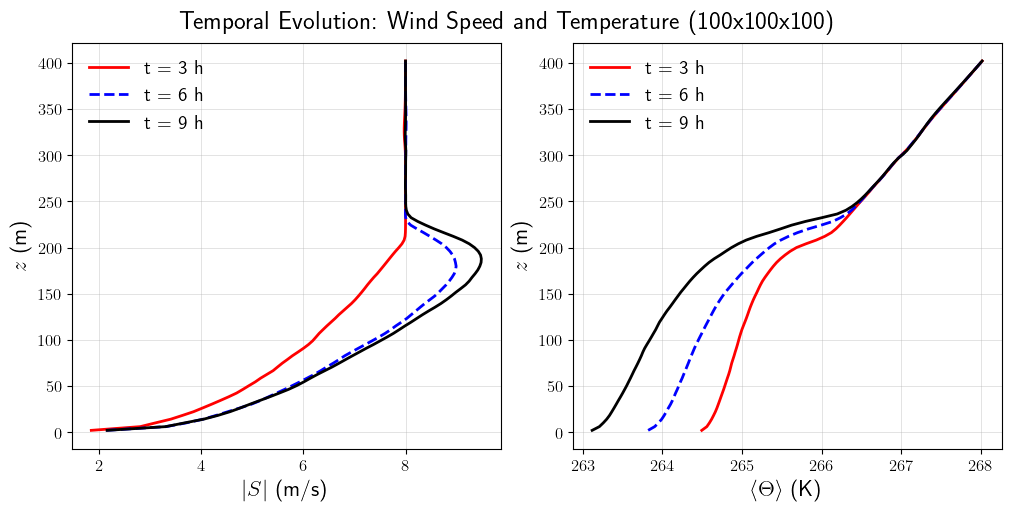

In [18]:
snap_hours = [3, 6, 9]
linestyles = ['-r', '--b', '-k']

def snap_index(t_h):
    return int(np.argmin(np.abs(t_hours * 3600.0 - t_h * 3600.0)))

fig, axs = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

for t_h, ls in zip(snap_hours, linestyles):
    idx = snap_index(t_h)
    with np.load(StatFiles3[idx]) as d:
        S_s  = np.sqrt(d['U']**2 + d['V']**2)
        TH_s = d['TH']
    plot_profile(S_s,  z_3, xlabel=r"$|S|$ (m/s)",                  linestyle=ls, label=f't = {t_h} h', ax=axs[0])
    plot_profile(TH_s, z_3, xlabel=r"$\langle \Theta \rangle$ (K)", linestyle=ls, label=f't = {t_h} h', ax=axs[1])

axs[0].grid()
axs[0].legend(frameon=False)
axs[1].grid()
axs[1].legend(frameon=False)

fig.suptitle("Temporal Evolution: Wind Speed and Temperature (100x100x100)", fontsize=18)
plt.show()